<a href="https://colab.research.google.com/github/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/blob/main/Notebooks/mvp_crimes_uf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#tabela base, com a quantidade d crimes por UF, mês a mês, entre janeiro de 2015 a dezembro de 2022.
dados_crimes = pd.read_excel('https://raw.githubusercontent.com/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/main/Arquivos/indicadoressegurancapublicauf%20(1).xlsx')
dados_crimes

,UF,Tipo Crime,Ano,Mês,Ocorrências
0,Acre,Estupro,2022,janeiro,31
1,Acre,Furto de veículo,2022,janeiro,50
2,Acre,Homicídio doloso,2022,janeiro,10
3,Acre,Lesão corporal seguida de morte,2022,janeiro,1
4,Acre,Roubo a instituição financeira,2022,janeiro,0
...,...,...,...,...,...
23015,Tocantins,Roubo a instituição financeira,2015,dezembro,6
23016,Tocantins,Roubo de carga,2015,dezembro,1
23017,Tocantins,Roubo de veículo,2015,dezembro,55
23018,Tocantins,Roubo seguido de morte (latrocínio),2015,dezembro,2


In [4]:
#Dataframe agrupando os crimes por ano em cada UF.
dados_crimes_ano = dados_crimes.groupby(['UF','Tipo Crime','Ano'])['Ocorrências'].sum().reset_index()
dados_crimes_ano

,UF,Tipo Crime,Ano,Ocorrências
0,Acre,Estupro,2015,42
1,Acre,Estupro,2016,36
2,Acre,Estupro,2017,108
3,Acre,Estupro,2018,260
4,Acre,Estupro,2019,330
...,...,...,...,...
1933,Tocantins,Tentativa de homicídio,2018,417
1934,Tocantins,Tentativa de homicídio,2019,518
1935,Tocantins,Tentativa de homicídio,2020,442
1936,Tocantins,Tentativa de homicídio,2021,359


In [5]:
#Dataframe dados crimes gerais por UF
dados_crimes_ano.groupby(['UF','Tipo Crime'])['Ocorrências'].sum().reset_index()

,UF,Tipo Crime,Ocorrências
0,Acre,Estupro,2062
1,Acre,Furto de veículo,3232
2,Acre,Homicídio doloso,2169
3,Acre,Lesão corporal seguida de morte,12
4,Acre,Roubo a instituição financeira,13
...,...,...,...
238,Tocantins,Roubo a instituição financeira,102
239,Tocantins,Roubo de carga,41
240,Tocantins,Roubo de veículo,5541
241,Tocantins,Roubo seguido de morte (latrocínio),110


In [6]:
#Dataframe ranking geral tipo crimes
df_crimes_uf_rank = dados_crimes_ano.groupby('Tipo Crime')['Ocorrências'].sum().sort_values(ascending = False).reset_index()
df_crimes_uf_rank

,Tipo Crime,Ocorrências
0,Furto de veículo,1851837
1,Roubo de veículo,1633495
2,Estupro,406831
3,Homicídio doloso,354868
4,Tentativa de homicídio,289959
5,Roubo de carga,148342
6,Roubo seguido de morte (latrocínio),14263
7,Lesão corporal seguida de morte,6100
8,Roubo a instituição financeira,5298


In [7]:
#tabela IBGE contendo as projeções das populações em cada UF de 2010 a 2060
dados_pop = pd.read_excel('https://raw.githubusercontent.com/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/main/Arquivos/IBGE_populacao__2010_2060.xlsx')
dados_pop

,UF,2010,2011,2012,2013,2014,2015,2016,2017,2018,...,2051,2052,2053,2054,2055,2056,2057,2058,2059,2060
0,Acre,765325,778499,792045,805014,818273,831665,844137,856457,869265,...,1168898,1172928,1176619,1179964,1182957,1185600,1187895,1189835,1191419,1192647
1,Alagoas,3195720,3213606,3230877,3247527,3263524,3279222,3293629,3307532,3322379,...,3401028,3386203,3370351,3353463,3335549,3316619,3296685,3275745,3253802,3230875
2,Amapá,694261,711453,728015,744809,762156,779416,796419,813084,829494,...,1249514,1257785,1265743,1273378,1280682,1287654,1294295,1300609,1306591,1312240
3,Amazonas,3553148,3618040,3684326,3751293,3819636,3887740,3952171,4015812,4080611,...,5638304,5664036,5688278,5710995,5732178,5751847,5770028,5786706,5801873,5815537
4,Bahia,14302571,14372994,14441531,14505033,14565807,14629018,14689684,14749868,14812617,...,14688641,14609436,14525993,14438328,14346461,14250434,14150307,14046125,13937968,13825958
5,Ceará,8623766,8681591,8738045,8792607,8847031,8905267,8962834,9018764,9076426,...,9675292,9649120,9620296,9588823,9554693,9517922,9478556,9436622,9392152,9345192
6,Distrito Federal,2639212,2681052,2722198,2763488,2805774,2848633,2890224,2931057,2972209,...,3782994,3788348,3792555,3795598,3797474,3798193,3797772,3796218,3793533,3789728
7,Espírito Santo,3596057,3642595,3689347,3736386,3784361,3832826,3879376,3925341,3972388,...,4895145,4903325,4910373,4916268,4921002,4924594,4927071,4928430,4928667,4927795
8,Goiás,6111792,6214241,6316302,6417591,6520857,6625528,6726130,6824504,6923655,...,8999139,9028359,9055541,9080667,9103727,9124748,9143789,9160881,9176042,9189311
9,Maranhão,6710964,6757213,6798830,6836179,6875302,6916244,6955099,6994148,7035055,...,7578099,7561887,7543659,7523382,7501013,7476542,7449981,7421317,7390534,7357617


In [8]:
#Tabela reorganizada para permitir melhor agregação dos seus dados.
dados_pop_long = dados_pop.melt(
    id_vars='UF',
    var_name = 'Ano',
    value_name= 'População'
)
dados_pop_long

,UF,Ano,População
0,Acre,2010,765325
1,Alagoas,2010,3195720
2,Amapá,2010,694261
3,Amazonas,2010,3553148
4,Bahia,2010,14302571
...,...,...,...
1372,Roraima,2060,984511
1373,Santa Catarina,2060,9015090
1374,São Paulo,2060,50596822
1375,Sergipe,2060,2598353


In [9]:
dados_pop_long['Ano'] = dados_pop_long['Ano'].astype(int)

In [10]:
dados_crimes_pop = dados_crimes_ano.merge(dados_pop_long,on=['UF','Ano'], how='left')
dados_crimes_pop

,UF,Tipo Crime,Ano,Ocorrências,População
0,Acre,Estupro,2015,42,831665
1,Acre,Estupro,2016,36,844137
2,Acre,Estupro,2017,108,856457
3,Acre,Estupro,2018,260,869265
4,Acre,Estupro,2019,330,881935
...,...,...,...,...,...
1933,Tocantins,Tentativa de homicídio,2018,417,1555229
1934,Tocantins,Tentativa de homicídio,2019,518,1572866
1935,Tocantins,Tentativa de homicídio,2020,442,1590248
1936,Tocantins,Tentativa de homicídio,2021,359,1607363


In [11]:
dados_crimes_pop['TX_100MIL'] = ((dados_crimes_pop['Ocorrências']/dados_crimes_pop['População'])*100000).round(2)
dados_crimes_pop

,UF,Tipo Crime,Ano,Ocorrências,População,TX_100MIL
0,Acre,Estupro,2015,42,831665,5.05
1,Acre,Estupro,2016,36,844137,4.26
2,Acre,Estupro,2017,108,856457,12.61
3,Acre,Estupro,2018,260,869265,29.91
4,Acre,Estupro,2019,330,881935,37.42
...,...,...,...,...,...,...
1933,Tocantins,Tentativa de homicídio,2018,417,1555229,26.81
1934,Tocantins,Tentativa de homicídio,2019,518,1572866,32.93
1935,Tocantins,Tentativa de homicídio,2020,442,1590248,27.79
1936,Tocantins,Tentativa de homicídio,2021,359,1607363,22.33


In [12]:
tabela = dados_crimes_pop.groupby(['UF','Tipo Crime'])['Ocorrências'].sum().reset_index()
tabela

,UF,Tipo Crime,Ocorrências
0,Acre,Estupro,2062
1,Acre,Furto de veículo,3232
2,Acre,Homicídio doloso,2169
3,Acre,Lesão corporal seguida de morte,12
4,Acre,Roubo a instituição financeira,13
...,...,...,...
238,Tocantins,Roubo a instituição financeira,102
239,Tocantins,Roubo de carga,41
240,Tocantins,Roubo de veículo,5541
241,Tocantins,Roubo seguido de morte (latrocínio),110


In [13]:
tabela = dados_crimes_pop.groupby(['UF','Tipo Crime','TX_100MIL'],as_index = False).agg({
    'Ocorrências':'sum'
}).round(2)[['UF','Tipo Crime','Ocorrências','TX_100MIL']]
tabela

,UF,Tipo Crime,Ocorrências,TX_100MIL
0,Acre,Estupro,36,4.26
1,Acre,Estupro,42,5.05
2,Acre,Estupro,108,12.61
3,Acre,Estupro,260,29.91
4,Acre,Estupro,280,31.30
...,...,...,...,...
1863,Tocantins,Tentativa de homicídio,356,23.68
1864,Tocantins,Tentativa de homicídio,395,24.32
1865,Tocantins,Tentativa de homicídio,417,26.81
1866,Tocantins,Tentativa de homicídio,442,27.79


In [14]:
df_crimes_sort = tabela.groupby('Tipo Crime')['Ocorrências'].sum().sort_values(ascending=False).reset_index()
df_crimes_sort

,Tipo Crime,Ocorrências
0,Furto de veículo,1851837
1,Roubo de veículo,1633495
2,Estupro,406831
3,Homicídio doloso,354868
4,Tentativa de homicídio,289959
5,Roubo de carga,148342
6,Roubo seguido de morte (latrocínio),14263
7,Lesão corporal seguida de morte,6100
8,Roubo a instituição financeira,5298


<Axes: ylabel='Tipo Crime'>

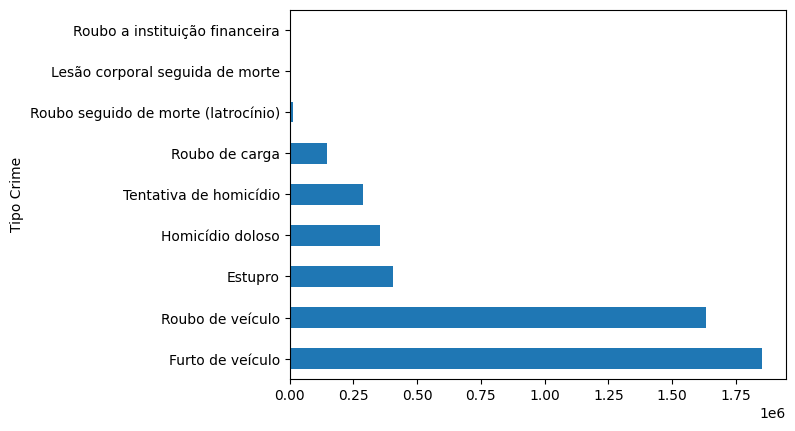

In [15]:
df_crimes_sort.plot(kind='barh', x='Tipo Crime',y='Ocorrências',legend=False)